In [22]:
import pandas as pd
import pandahouse as ph
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Загрузка данных

In [23]:
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

In [24]:
q = '''
SELECT 
    user_id,
    exp_group,
    SUM(action='like') AS likes,
    SUM(action='view') AS views,
    likes/views AS ctr
FROM simulator_20260220.feed_actions
WHERE toDate(time) BETWEEN '2026-01-30' AND '2026-02-05'
    AND exp_group IN (1, 2)
GROUP BY user_id, exp_group
'''

In [25]:
df = ph.read_clickhouse(q, connection=connection)
df.head()

,user_id,exp_group,likes,views,ctr
0,109963,1,3,15,0.200000
1,26117,1,32,141,0.226950
2,138232,1,18,73,0.246575
3,18392,1,7,32,0.218750
4,26295,1,39,141,0.276596


**Распределение данных**

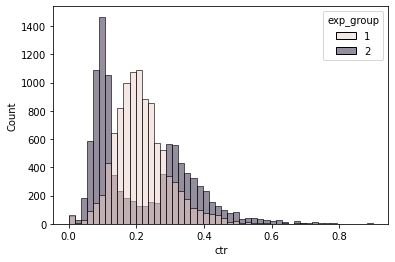

In [26]:
sns.histplot(data=df, x='ctr', hue='exp_group', bins=50, alpha=0.5)
plt.show()

Контрольная группа распределена близко к нормальному, а тестовая группа бимодальное распределение. Это уже намекает на неоднородное влияние алгоритма.

# Проведение A/B-теста

**t-тест**

In [27]:
ctr1 = df[df['exp_group'] == 1].values
ctr2 = df[df['exp_group'] == 2].values

In [28]:
stats.ttest_ind(df[df.exp_group == 1].ctr,
                df[df.exp_group == 2].ctr,
                equal_var=False)

Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)

**Разница**: не значимо. Средние CTR почти равны, но распределения разные

**тест Манна-Уитни**

In [29]:
stats.mannwhitneyu(df[df.exp_group == 1].ctr,
                df[df.exp_group == 2].ctr)

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)

**Разница**: значимо. Распределения сильно различаются.

**Пуассоновский бутстреп**

In [30]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):
    
    poisson_bootstraps1 = stats.poisson(1).rvs((n_bootstrap, len(likes1))).astype(np.int64)
    
    poisson_bootstraps2 = stats.poisson(1).rvs((n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)
    
    return globalCTR1, globalCTR2

In [31]:
likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()

In [32]:
ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)

<Axes: ylabel='Count'>

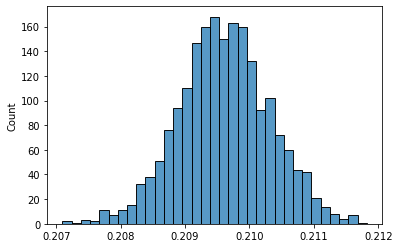

In [33]:
sns.histplot(ctr1)

<Axes: ylabel='Count'>

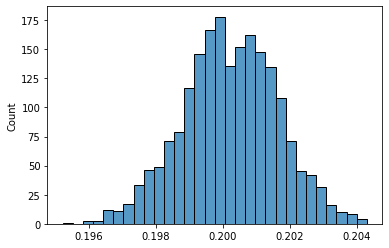

In [34]:
sns.histplot(ctr2)

<Axes: ylabel='Count'>

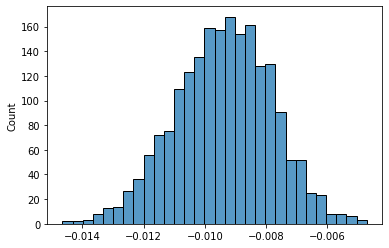

In [35]:
sns.histplot(ctr2 - ctr1)

**Разница**: значимо ухудшение. Видно, что в тесте CTR ниже.

**t-тест на сглаженном CTR**

In [42]:
def get_smoothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr

In [43]:
global_ctr = df[df.exp_group == 1].likes.sum() / df[df.exp_group == 1].views.sum()

In [44]:
alpha = 5
df['smoothed_ctr'] = df.apply(
    lambda row: get_smoothed_ctr(row.likes, row.views, global_ctr, alpha),
    axis=1
)

In [45]:
ctrl = df[df.exp_group == 1].smoothed_ctr
test = df[df.exp_group == 2].smoothed_ctr

In [46]:
stats.ttest_ind(ctrl,
                test,
                equal_var=False)

Ttest_indResult(statistic=1.2447034376197188, pvalue=0.2132595139151033)

**Разница**: значимо. t-тест на сглаженном CTR показывает разницу средних CTR.

**Бакетное преобразование**

In [47]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [48]:
bucket_size = 50

In [49]:
df_shuffled['bucket'] = np.arange(len(df_shuffled)) // bucket_size

In [50]:
buckets = df_shuffled.groupby(['exp_group', 'bucket']).agg(
    total_likes=('likes', 'sum'),
    total_views=('views', 'sum')
).reset_index()

In [51]:
buckets['bucket_ctr'] = buckets['total_likes'] / buckets['total_views']

In [52]:
ctrl_buckets = buckets[buckets['exp_group'] == 1]['bucket_ctr']
test_buckets = buckets[buckets['exp_group'] == 2]['bucket_ctr']

In [53]:
stats.ttest_ind(ctrl_buckets,
                test_buckets,
                equal_var=False)

Ttest_indResult(statistic=5.866571101993141, pvalue=7.517719230117517e-09)

**Разница**: значимо. CTR по бакетам различается.

In [54]:
stats.mannwhitneyu(ctrl_buckets,
                test_buckets)

MannwhitneyuResult(statistic=99527.5, pvalue=3.6980322294477826e-10)

**Разница**: значимо. ПОдтверждает различие распределений бакетов.

# Вывод

Средние не изменились, но распределения стали разными. Это значит, что алгоритм по-разному повлиял на пользователей: одни стали кликать чаще, другие - реже, но в среднем осталось так же.

Бутстрап и бакетизация показывают значимое снижение CTR. То есть вовлечённость упала.

**Рекомендации**
Не раскатывать новый алгоритм на всех пользователей.

Необходимо:
- Провести сегментный анализа - выяснить какие пользователи дают правый и левый пик.
- Если семгменты найдутся, можно рассмотреть возможность включения алгоритма только для тех, где он даёт улучшение, либо доработать его для остальных.
- Если сегменты не выявляются, значит алгоритм сырой.